<a href="https://colab.research.google.com/github/umergulkaleem/Machine_Learning/blob/main/CNN_prac.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("biancaferreira/african-wildlife")

print("Path to dataset files:", path)
print("Files in dataset:", os.listdir(path))

100%|██████████| 448M/448M [00:21<00:00, 22.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/biancaferreira/african-wildlife/versions/1
Files in dataset: ['zebra', 'buffalo', 'elephant', 'rhino']


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Step 1: Set dataset path
data_dir = path

# Step 2: Load images and labels
def load_images_and_labels(data_dir, target_size=(150, 150)):
    images = []
    labels = []
    class_names = sorted(os.listdir(data_dir))

    for class_idx, class_name in enumerate(class_names):
        class_folder = os.path.join(data_dir, class_name)
        if os.path.isdir(class_folder):
            for img_name in os.listdir(class_folder):
                if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    img_path = os.path.join(class_folder, img_name)
                    img = load_img(img_path, target_size=target_size)
                    img_array = img_to_array(img)
                    images.append(img_array)
                    labels.append(class_idx)

    return np.array(images), np.array(labels), class_names

print("Loading data...")
X, y, class_names = load_images_and_labels(data_dir)
print(f"Loaded {len(X)} images across {len(class_names)} classes.")

Loading data...
Loaded 1504 images across 4 classes.


In [ ]:

# Normalize pixel values
X = X / 255.0

# Convert labels to one-hot encoded format
y = to_categorical(y, num_classes=len(class_names))

# Step 3: Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")


Training samples: 1203, Test samples: 301


In [ ]:

# Step 4: Create data generators
train_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator()

train_generator = train_datagen.flow(X_train, y_train, batch_size=32)
val_generator = val_datagen.flow(X_test, y_test, batch_size=32)


In [ ]:

# Step 5: Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



In [ ]:
# Step 6: Train the model
history = model.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator)
)

# Save the model
model.save("animal_classifier_model.h5")
print("Model saved successfully.")

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 18s 310ms/step - accuracy: 0.2481 - loss: 1.4082 - val_accuracy: 0.3654 - val_loss: 1.2617
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 167ms/step - accuracy: 0.4243 - loss: 1.2391 - val_accuracy: 0.5980 - val_loss: 1.0278
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 185ms/step - accuracy: 0.5377 - loss: 1.0597 - val_accuracy: 0.4452 - val_loss: 1.1930
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 163ms/step - accuracy: 0.5753 - loss: 0.9499 - val_accuracy: 0.6312 - val_loss: 0.8807
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 169ms/step - accuracy: 0.6018 - loss: 0.9024 - val_accuracy: 0.6877 - val_loss: 0.8608
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 184ms/step - accuracy: 0.6387 - loss: 0.8444 - val_accuracy: 0.6113 - val_loss: 0.9031
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 159ms/step - accuracy: 0.6145 - loss: 0.8788 - val_accuracy: 0.6512 - val_loss: 0.9038
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 172ms/step - accuracy: 0.6556 - loss: 0.8152 - val_

Model saved successfully.


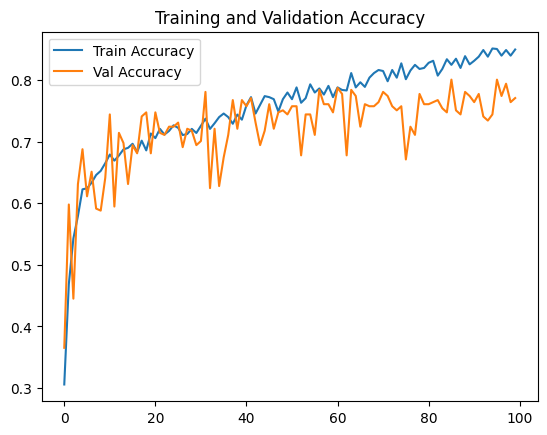

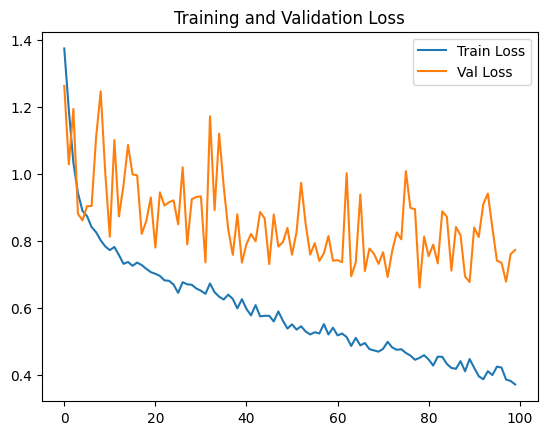

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


In [ ]:
from tensorflow.keras.models import load_model

# Load the model
loaded_model = load_model("animal_classifier_model.h5")
print("Model loaded successfully.")


Model loaded successfully.


In [ ]:
# Step 8: Make prediction on a single image
def predict_image_with_loaded_model(img_path, model, class_names):
    img = load_img(img_path, target_size=(150, 150))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    class_idx = np.argmax(prediction)
    class_label = class_names[class_idx]
    print(f"Predicted class: {class_label} (Confidence: {prediction[0][class_idx]*100:.2f}%)")


Image_path = 'buffalo.jpg'
predict_image_with_loaded_model(Image_path, loaded_model, class_names)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted class: elephant (Confidence: 48.91%)


In [ ]:
Image_path = 'zebra.jpg'
predict_image_with_loaded_model(Image_path, loaded_model, class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted class: zebra (Confidence: 100.00%)


In [ ]:
Image_path = 'elephant.jpg'
predict_image_with_loaded_model(Image_path, loaded_model, class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted class: elephant (Confidence: 54.44%)


In [ ]:
Image_path = 'rhino.jpg'
predict_image_with_loaded_model(Image_path, loaded_model, class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted class: rhino (Confidence: 86.68%)


In [ ]:
Image_path = '/content/extracted_dataset/animals/animals/beetle/02b34c63a2.jpg'
predict_image_with_loaded_model(Image_path, loaded_model, class_names)

In [ ]:
Image_path = 'buffalo1.jpg'
predict_image_with_loaded_model(Image_path, loaded_model, class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted class: buffalo (Confidence: 100.00%)
